# 🌡️ HVAC Time-Series EDA
### Dataset: `HVAC_NE_EC_19-21.csv`  |  Oct 2019 – Apr 2021
**Goal:** Explore all 10 features, understand temporal patterns, and select the most informative features for anomaly detection.

---

In [1]:
!pip install pandas matplotlib seaborn numpy



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 0. Install & Imports

In [2]:
# Install dependencies (run once)
# !pip install pandas matplotlib seaborn numpy

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("✅ All imports OK")

✅ All imports OK


## 1. Load Data & Basic Inspection

In [3]:
DATA_PATH = 'HVAC_NE_EC_19-21.csv'   # ← update path if needed

df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
df = df.set_index('Timestamp').sort_index()

print(f"Shape      : {df.shape}")
print(f"Date range : {df.index.min()} → {df.index.max()}")
print(f"Freq       : {df.index[1] - df.index[0]}")
df.head()

Shape      : (33888, 10)
Date range : 2019-10-14 22:00:00+00:00 → 2021-04-14 21:45:00+00:00
Freq       : 0 days 00:15:00


,T_Supply,T_Return,SP_Return,T_Saturation,T_Outdoor,RH_Supply,RH_Return,RH_Outdoor,Energy,Power
Timestamp,,,,,,,,,,
2019-10-14 22:00:00+00:00,19.859999,20.469999,18.5,19.02,20.299999,71.110001,58.919998,79.5,0.0,0.0
2019-10-14 22:15:00+00:00,19.855000,20.430000,18.5,19.02,20.299999,71.320000,59.000000,82.0,0.0,0.0
2019-10-14 22:30:00+00:00,19.850000,20.410000,18.5,19.02,20.299999,71.470001,59.109997,79.5,0.0,0.0
2019-10-14 22:45:00+00:00,19.840000,20.379999,18.5,19.08,20.299999,71.439995,59.309998,77.0,0.0,0.0
2019-10-14 23:00:00+00:00,19.830000,20.350000,18.5,19.08,20.299999,71.580002,59.559998,79.5,0.0,0.0


In [4]:
# Data types & missing values
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().mean()*100).round(2),
    'unique' : df.nunique(),
})
print(info.to_string())

                dtype  missing  missing%  unique
T_Supply      float64        0       0.0    2996
T_Return      float64        0       0.0    2196
SP_Return     float64        0       0.0       6
T_Saturation  float64        0       0.0     709
T_Outdoor     float64        0       0.0     302
RH_Supply     float64        0       0.0    5028
RH_Return     float64        0       0.0    5155
RH_Outdoor    float64        0       0.0     425
Energy        float64        0       0.0      24
Power         float64        0       0.0     175


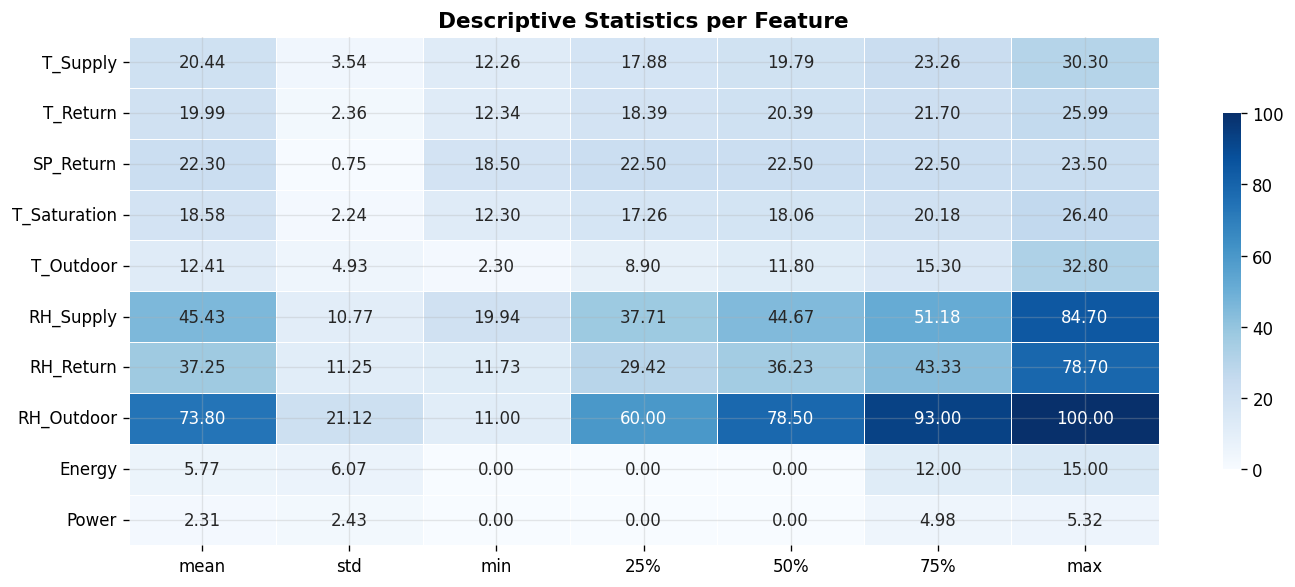

                   mean        std        min        25%        50%        75%         max
T_Supply      20.436936   3.535683  12.264999  17.879999  19.785000  23.256249   30.295000
T_Return      19.994425   2.357756  12.344999  18.389999  20.385000  21.699999   25.990000
SP_Return     22.302290   0.745301  18.500000  22.500000  22.500000  22.500000   23.500000
T_Saturation  18.580051   2.237516  12.300000  17.260000  18.059999  20.180000   26.400000
T_Outdoor     12.414164   4.925918   2.300000   8.900000  11.800000  15.300000   32.799999
RH_Supply     45.433972  10.765867  19.939999  37.709999  44.669998  51.180000   84.699997
RH_Return     37.251636  11.253552  11.730000  29.420000  36.230000  43.329998   78.699997
RH_Outdoor    73.803308  21.116373  11.000000  60.000000  78.500000  93.000000  100.000000
Energy         5.769196   6.074394   0.000000   0.000000   0.000000  12.000000   15.000000
Power          2.308225   2.432835   0.000000   0.000000   0.000000   4.980000    5.316000

In [5]:
# Descriptive statistics — heatmap of key stats
desc = df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(desc, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Descriptive Statistics per Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print(desc.to_string())

## 2. Overview Time-Series Plot
All 10 signals across the full 18-month timeline.

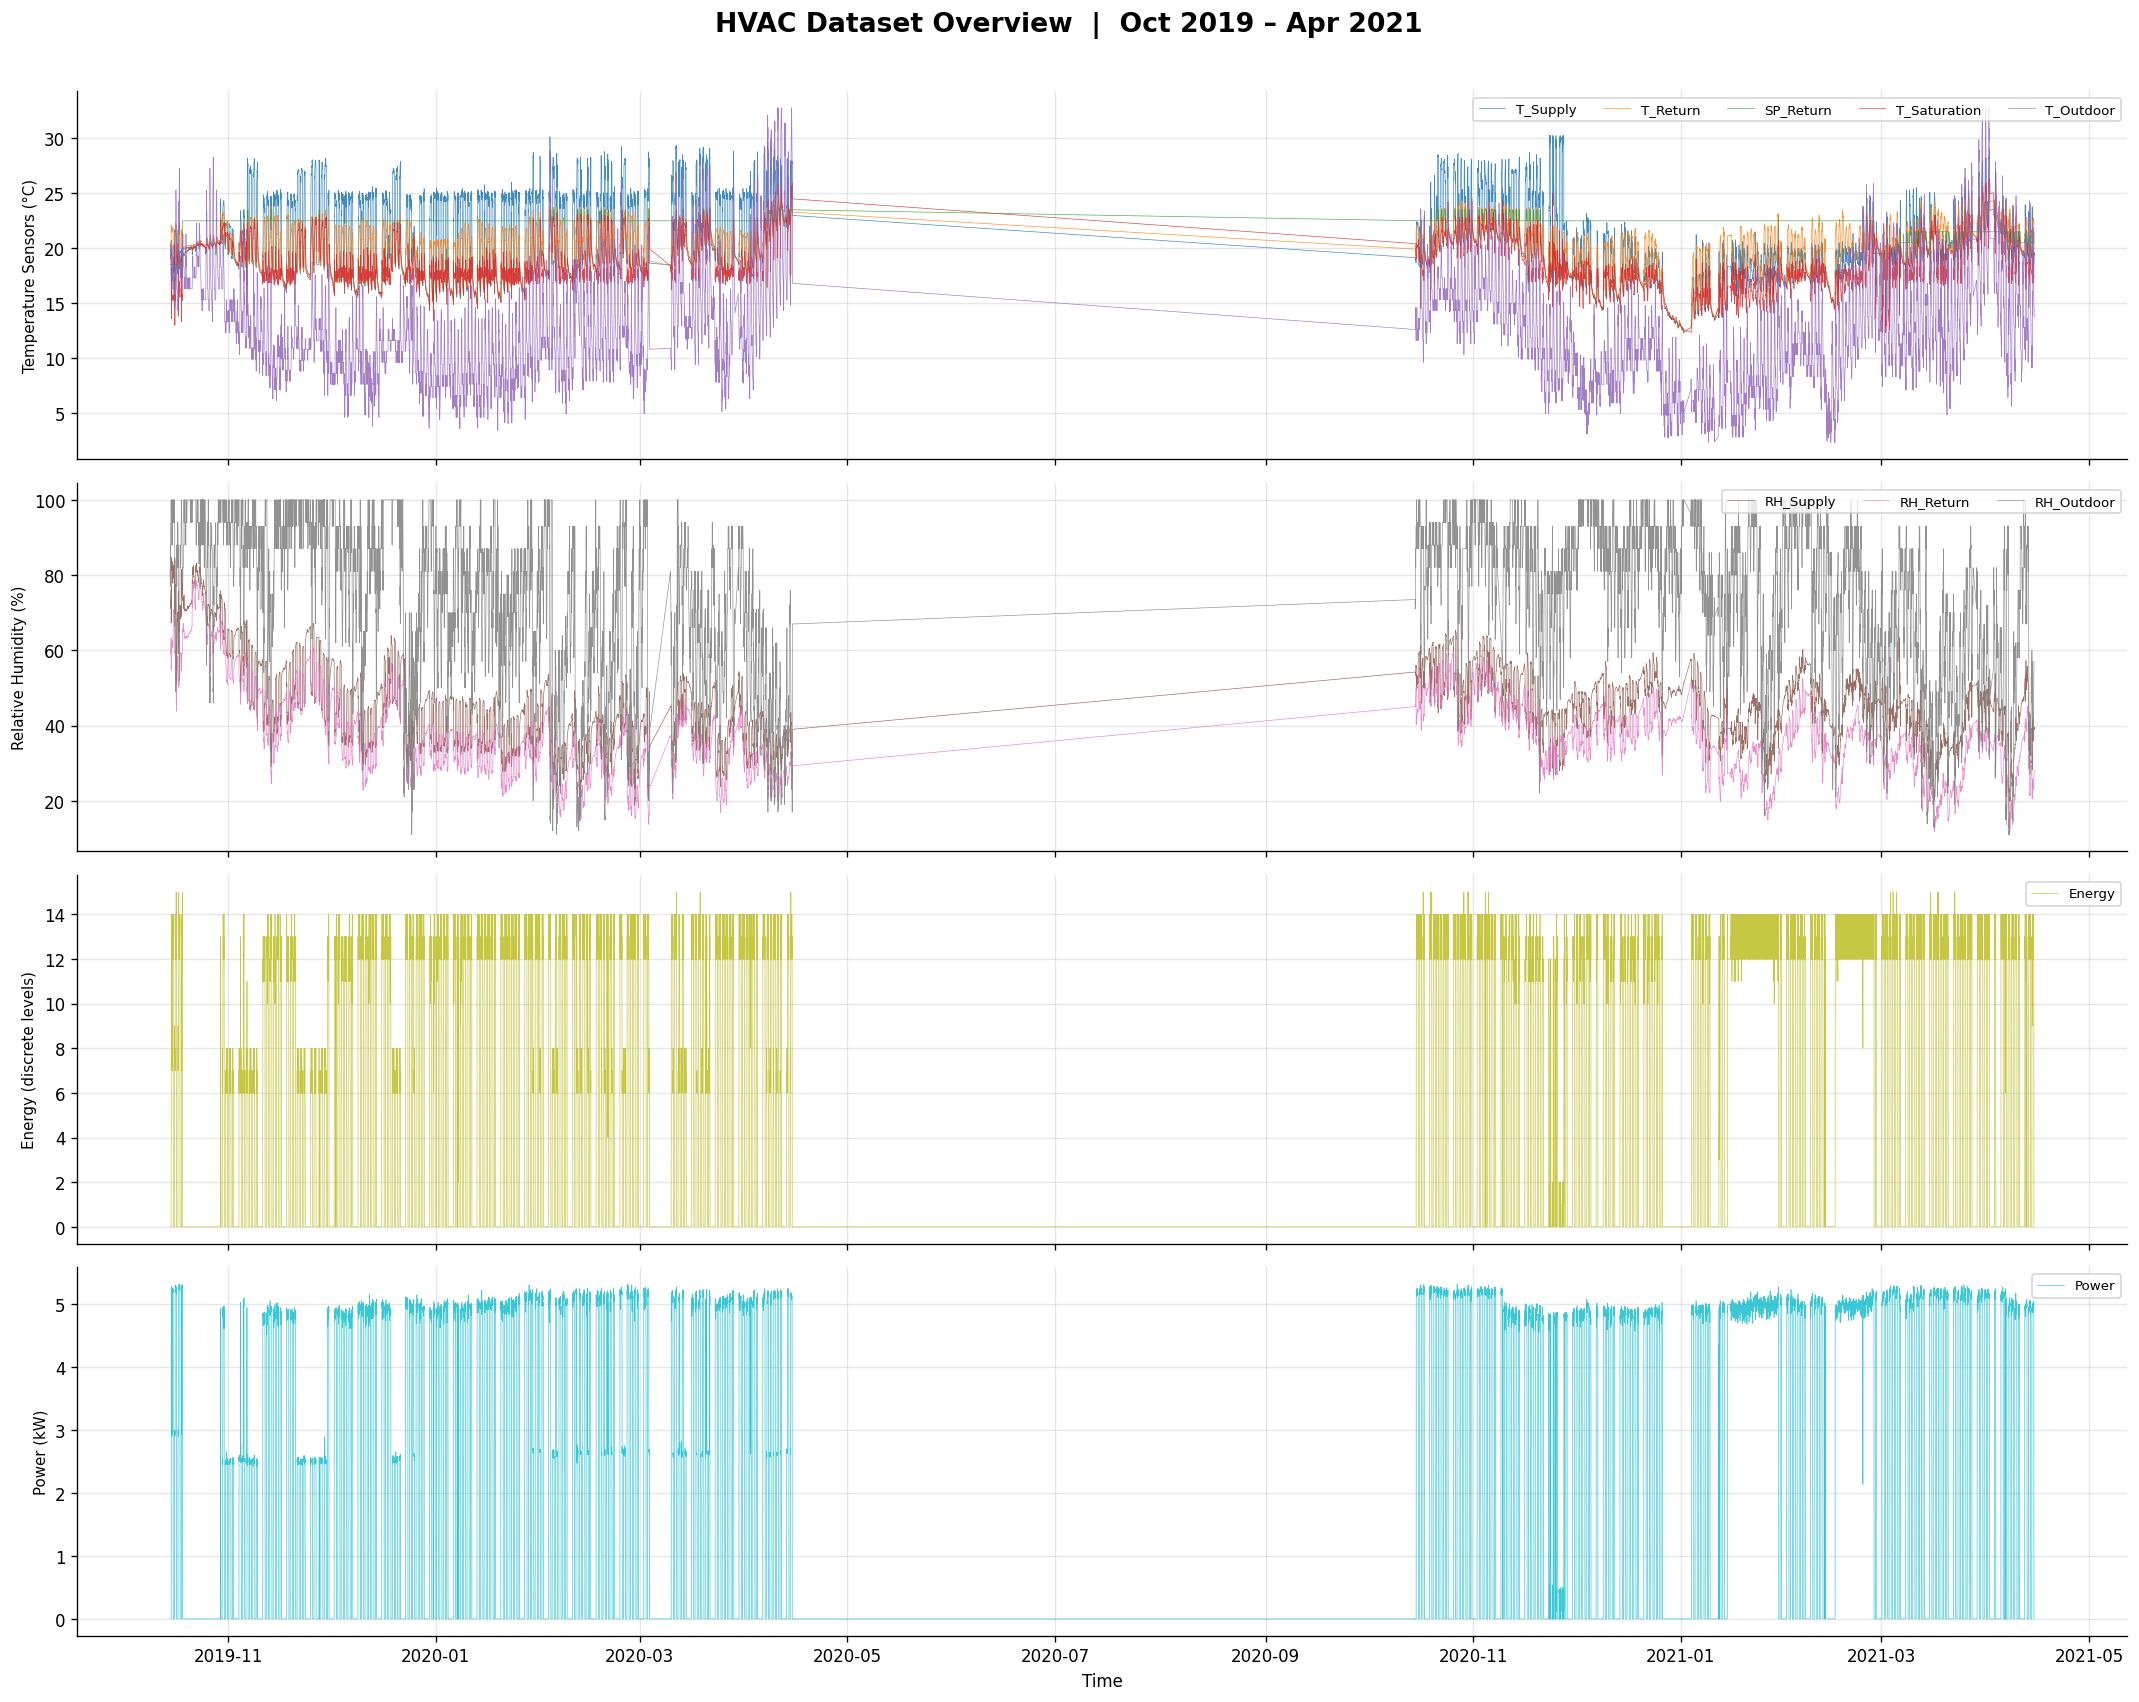

In [ ]:
TEMP_COLS   = ['T_Supply', 'T_Return', 'SP_Return', 'T_Saturation', 'T_Outdoor']
RH_COLS     = ['RH_Supply', 'RH_Return', 'RH_Outdoor']
ENERGY_COLS = ['Energy', 'Power']
ALL_NUM     = TEMP_COLS + RH_COLS + ENERGY_COLS
CMAP        = sns.color_palette("tab10", n_colors=len(ALL_NUM))

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle('HVAC Dataset Overview  |  Oct 2019 – Apr 2021',
             fontsize=16, fontweight='bold', y=1.01)

groups = [TEMP_COLS, RH_COLS, ['Energy'], ['Power']]
titles = ['Temperature Sensors (°C)', 'Relative Humidity (%)',
          'Energy (discrete levels)', 'Power (kW)']

for ax, cols, title, offset in zip(axes, groups, titles, [0, 5, 8, 9]):
    for i, c in enumerate(cols):
        ax.plot(df.index, df[c], label=c, linewidth=0.4, alpha=0.85,
                color=CMAP[offset + i])
    ax.set_ylabel(title, fontsize=9)
    ax.legend(loc='upper right', fontsize=8, ncol=len(cols))

axes[-1].set_xlabel('Time', fontsize=10)
plt.tight_layout()
plt.savefig('01_overview_timeseries.png', dpi=130, bbox_inches='tight')
plt.show()

#either ~0 (HVAC OFF) or ~5kW (HVAC ON) - power kw

## How to Read the HVAC Overview Time-Series

**Each g = one group of sensors. X-axis = time. Y-axis = the value.**

---

### The 4 panels top to bottom

**graph 1 — Temperature (°C)**
- All 5 temp sensors running together
- You can see **seasonal rhythm** — dips in winter (Dec–Feb), rises in summer
- T_Outdoor (purple) swings the most — it's outside, uncontrolled
- SP_Return (red) barely moves — it's just the target setpoint, always ~22°C

**g 2 — Relative Humidity (%)**
- RH_Outdoor (grey) is all over the place, 20–100% — weather driven
- RH_Supply and RH_Return (pink/brown) are tighter — indoor air, more stable

**g 3 — Energy (discrete levels)**
- Jumps between fixed levels (0, 8, 12, 13, 14, 15) — not continuous
- This is why we dropped it — it's basically just a **step counter**, redundant with Power

**g 4 — Power (kW)**
- Either ~0 (HVAC OFF) or ~5kW (HVAC ON) — binary behavior
- Clear on/off cycling pattern

**There's a big gap from ~May 2020 to ~Oct 2020** — all 4 panels go flat/zero. That's roughly **5 months of missing or zero data**. This is likely a shutdown (COVID lockdown period fits exactly).

This matters a lot for your anomaly model — you'll need to **exclude or handle this gap** during preprocessing, otherwise the model will treat the restart in Oct 2020 as a giant anomaly.

## 3. Feature Distributions & Boxplots
Histogram (top) + boxplot (bottom) for every feature. Red line = mean.

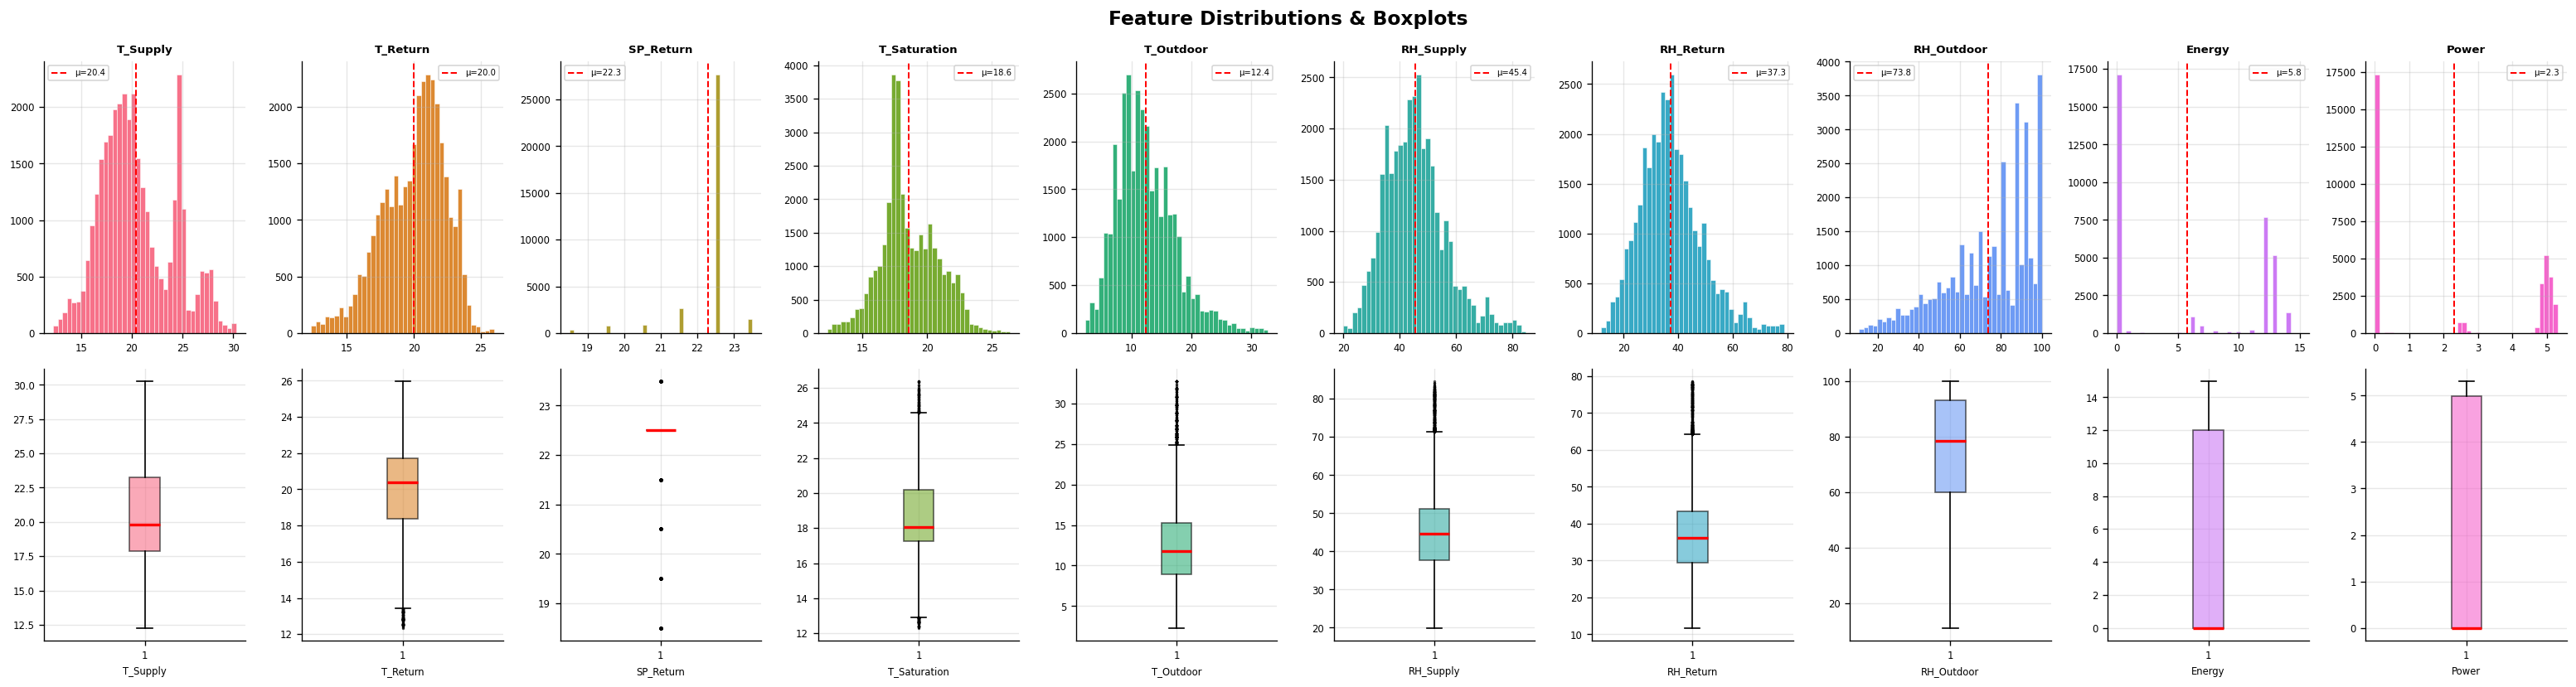

In [14]:
pal = sns.color_palette("husl", 10)
fig, axes = plt.subplots(2, 10, figsize=(26, 7))
fig.suptitle('Feature Distributions & Boxplots', fontsize=14, fontweight='bold')

for i, col in enumerate(ALL_NUM):
    # Histogram
    ax_h = axes[0, i]
    ax_h.hist(df[col].dropna(), bins=40, color=pal[i],
              edgecolor='white', linewidth=0.3)
    ax_h.set_title(col, fontsize=8, fontweight='bold')
    ax_h.tick_params(labelsize=7)
    mu = df[col].mean()
    ax_h.axvline(mu, color='red', linewidth=1.2, linestyle='--',
                 label=f'μ={mu:.1f}')
    ax_h.legend(fontsize=6)

    # Boxplot
    ax_b = axes[1, i]
    ax_b.boxplot(df[col].dropna(), patch_artist=True,
                 boxprops=dict(facecolor=pal[i], alpha=0.6),
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='.', markersize=2, alpha=0.4))
    ax_b.set_xlabel(col, fontsize=7)
    ax_b.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('02_distributions_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()

#Energy and Power are bimodal (two states: ON/OFF).
#SP_Return is nearly constant. Everything else is unimodal and roughly normal — 
#which is exactly what anomaly detection models expect as "normal behavior" to learn from.



## 4. Correlation Analysis
Left: full Pearson matrix.  Right: ranked correlation with **Power** (our anomaly proxy target).

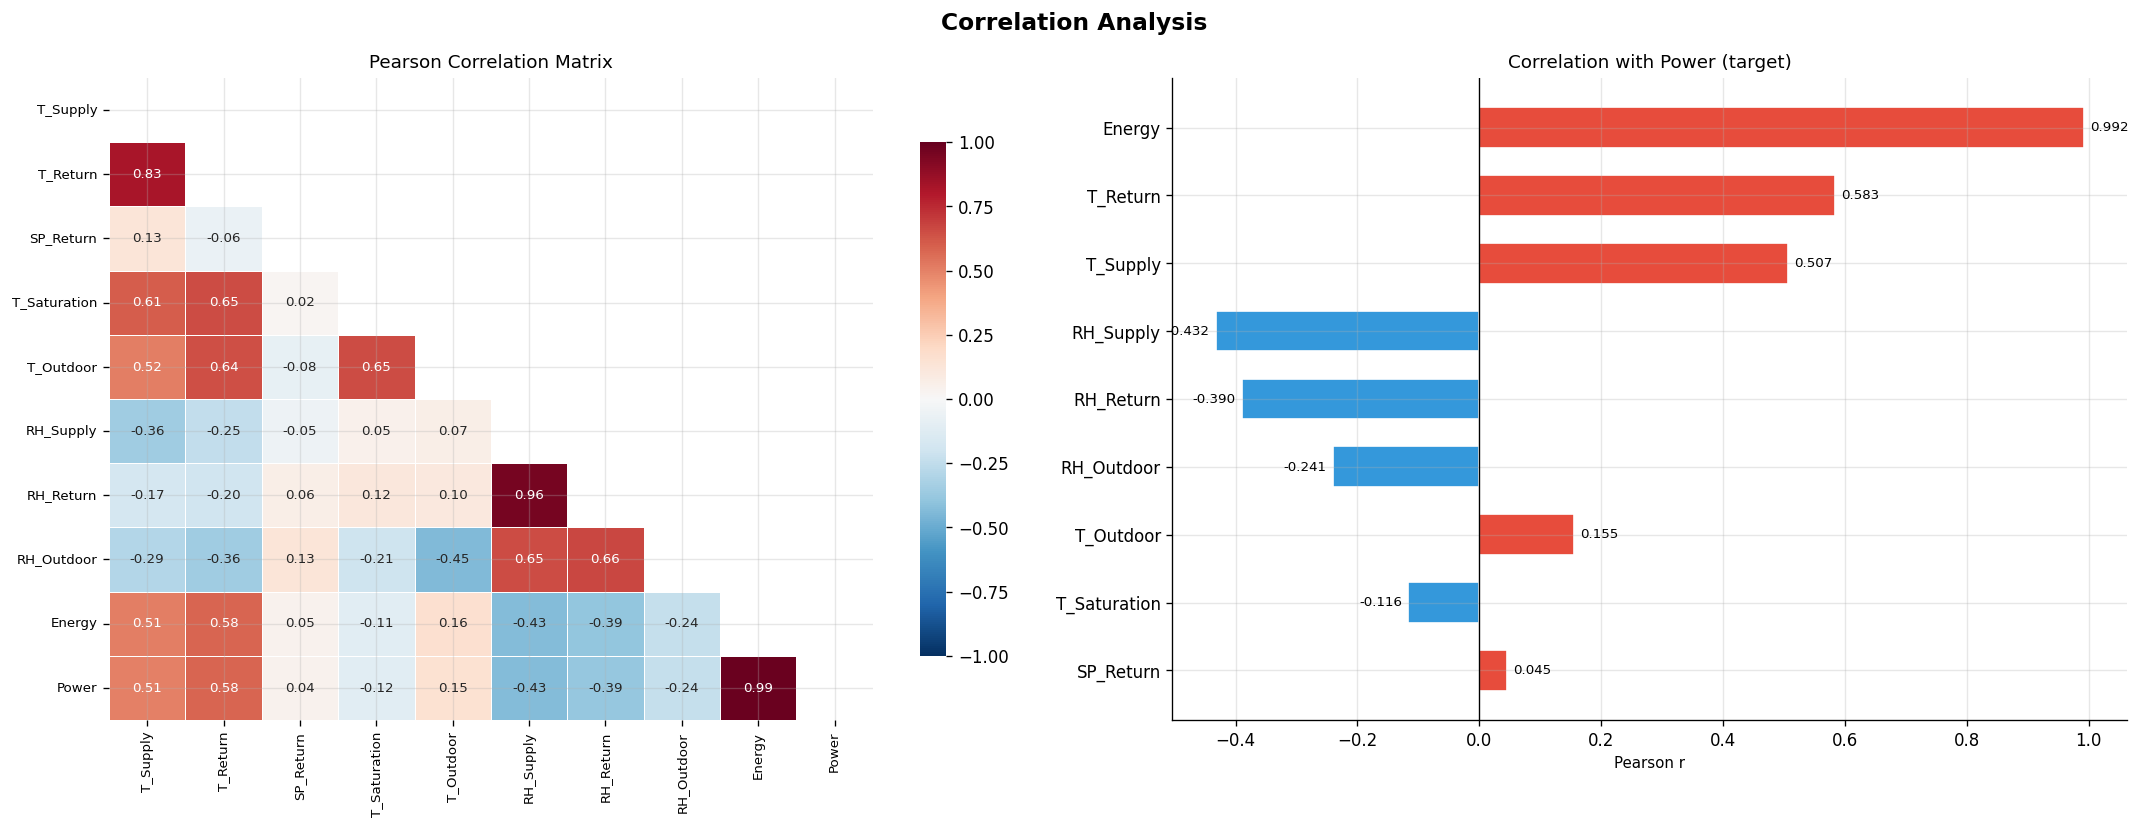


=== Correlation with Power (ranked) ===
Energy          0.991744
T_Return        0.583019
T_Supply        0.507270
RH_Supply      -0.432204
RH_Return      -0.389790
RH_Outdoor     -0.240783
T_Outdoor       0.154859
T_Saturation   -0.116330
SP_Return       0.044861


In [8]:
corr = df[ALL_NUM].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Matrix', fontsize=11)
axes[0].tick_params(labelsize=8)

corr_power = corr['Power'].drop('Power').sort_values(key=abs, ascending=True)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_power]
axes[1].barh(corr_power.index, corr_power.values, color=colors,
             edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Power (target)', fontsize=11)
axes[1].set_xlabel('Pearson r', fontsize=9)
for i, v in enumerate(corr_power.values):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('03_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

print("\n=== Correlation with Power (ranked) ===")
print(corr_power.sort_values(key=abs, ascending=False).to_string())

## 5. Temporal Patterns & Operating State
- Monthly average temperatures  
- HVAC operating % by month  
- Day-of-week × hour power heatmap  
- Daily ΔT (Supply − Return) over time  
- Energy level distribution

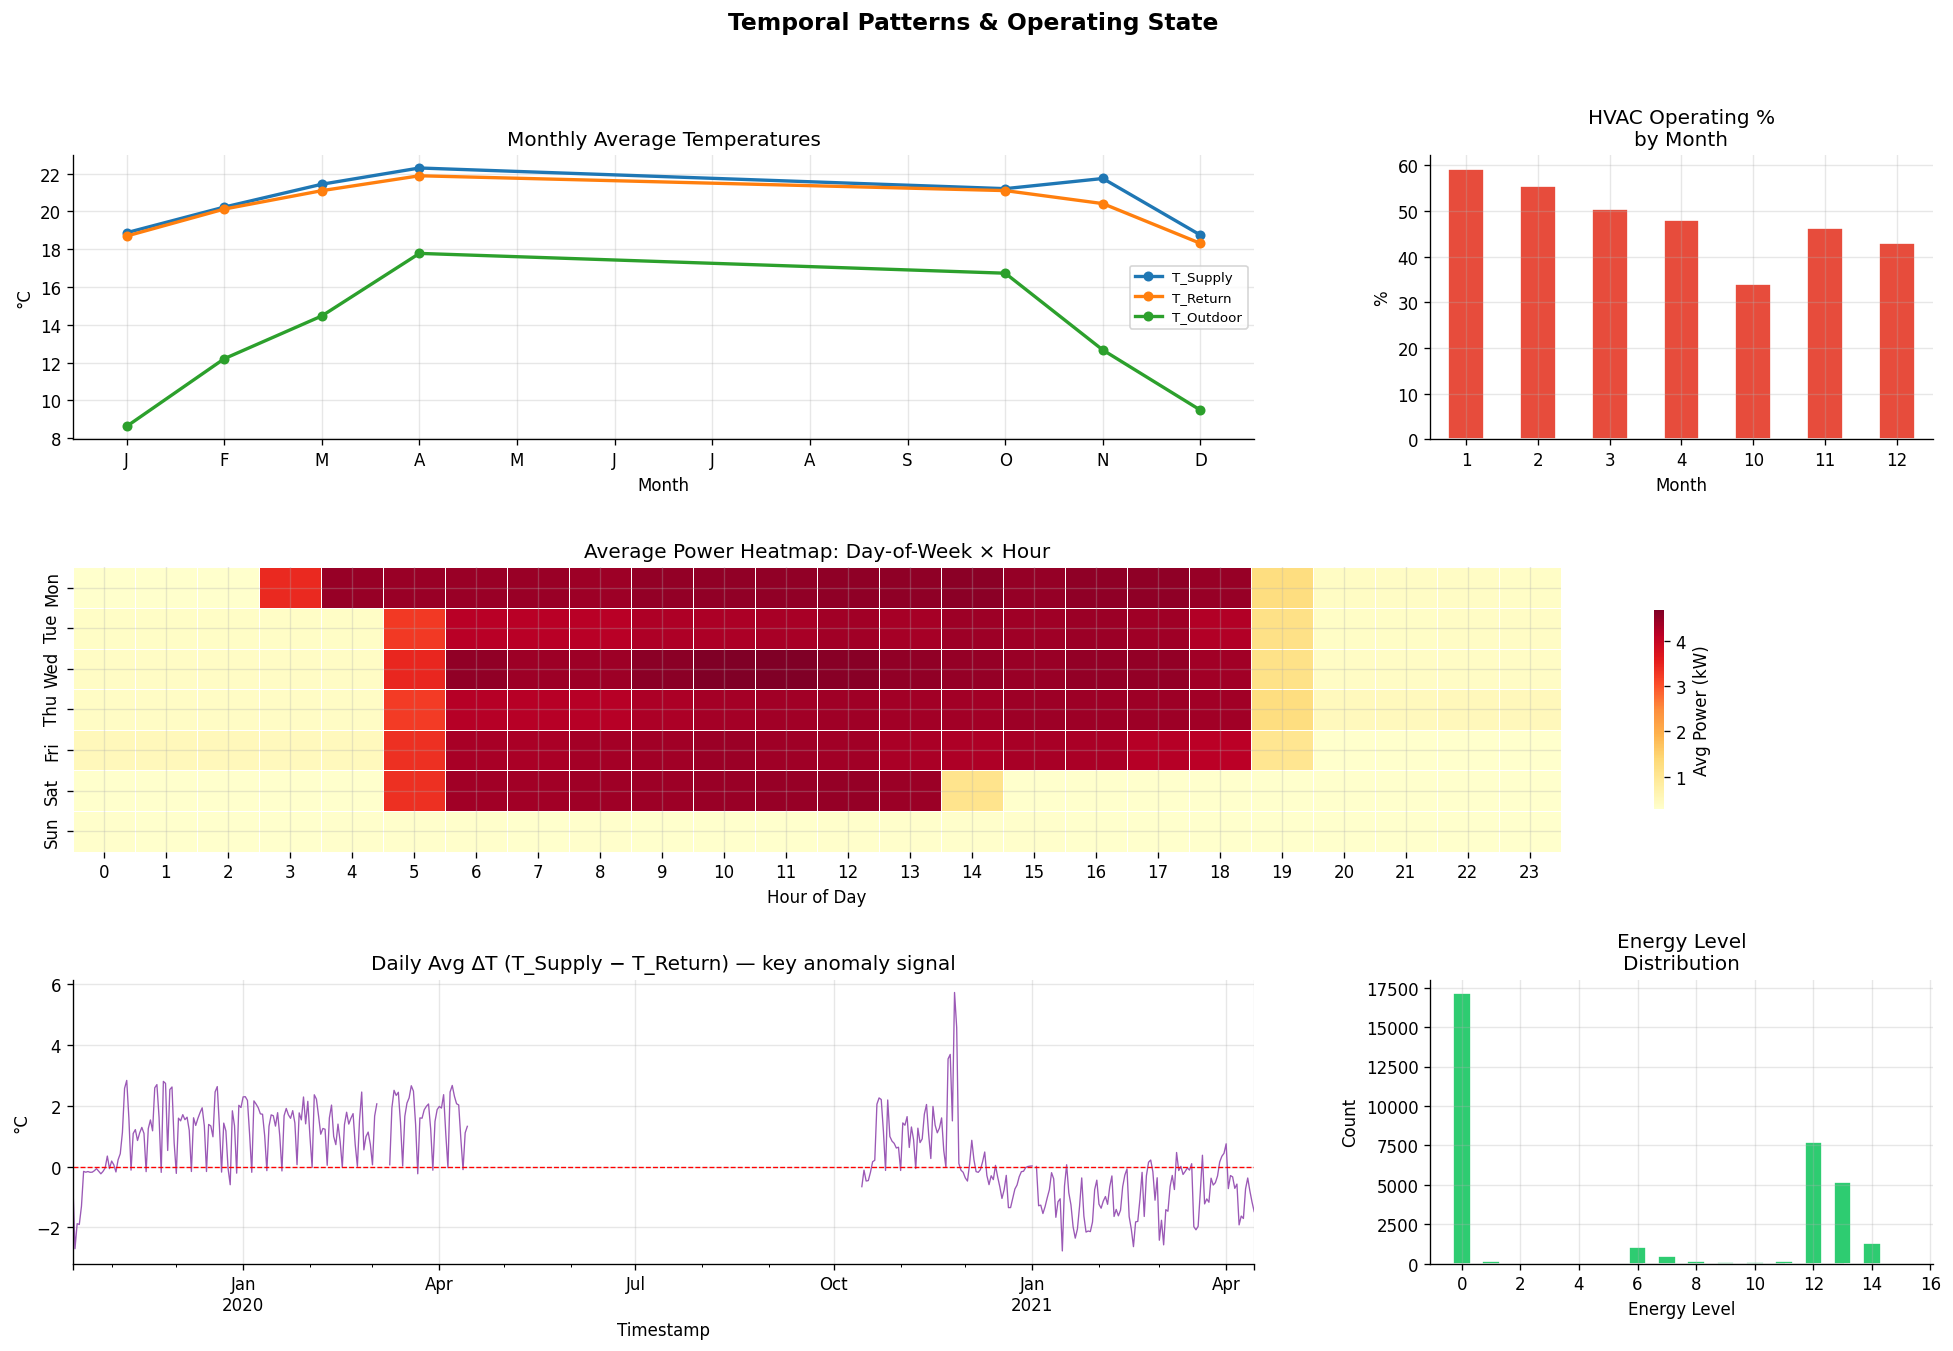

In [ ]:
df['month']     = df.index.month
df['hour']      = df.index.hour
df['operating'] = (df['Power'] > 0).astype(int)
df['T_delta']   = df['T_Supply'] - df['T_Return']

season_map = {10:'Autumn',11:'Autumn',12:'Winter', 1:'Winter', 2:'Winter',
               3:'Spring', 4:'Spring', 5:'Spring',  6:'Summer',
               7:'Summer', 8:'Summer', 9:'Autumn'}
df['season'] = df['month'].map(season_map)

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Temporal Patterns & Operating State', fontsize=14, fontweight='bold')
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# Monthly avg temp
ax1 = fig.add_subplot(gs[0, :2])
monthly = df.groupby('month')[['T_Supply','T_Return','T_Outdoor']].mean()
monthly.plot(ax=ax1, marker='o', linewidth=2, markersize=5)
ax1.set_title('Monthly Average Temperatures')
ax1.set_xlabel('Month'); ax1.set_ylabel('°C')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.legend(fontsize=8)

# Operating fraction per month
ax2 = fig.add_subplot(gs[0, 2])
op_month = df.groupby('month')['operating'].mean() * 100
op_month.plot(kind='bar', ax=ax2, color='#e74c3c', edgecolor='white')
ax2.set_title('HVAC Operating %\nby Month')
ax2.set_ylabel('%'); ax2.set_xlabel('Month')
ax2.tick_params(axis='x', rotation=0)

# Day-of-week × hour heatmap
ax3 = fig.add_subplot(gs[1, :])
pivot = df.pivot_table(values='Power', index=df.index.dayofweek,
                       columns='hour', aggfunc='mean')
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot, ax=ax3, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Avg Power (kW)', 'shrink':0.7})
ax3.set_title('Average Power Heatmap: Day-of-Week × Hour')
ax3.set_xlabel('Hour of Day')

# T_delta over time
ax4 = fig.add_subplot(gs[2, :2])
df['T_delta'].resample('1D').mean().plot(ax=ax4, color='#9b59b6', linewidth=0.8)
ax4.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax4.set_title('Daily Avg ΔT (T_Supply − T_Return) — key anomaly signal')
ax4.set_ylabel('°C')

# Energy level distribution
ax5 = fig.add_subplot(gs[2, 2])
val_counts = df['Energy'].value_counts().sort_index()
ax5.bar(val_counts.index, val_counts.values, color='#2ecc71',
        edgecolor='white', width=0.6)
ax5.set_title('Energy Level\nDistribution')
ax5.set_xlabel('Energy Level'); ax5.set_ylabel('Count')

plt.savefig('04_temporal_patterns.png', dpi=130, bbox_inches='tight')
plt.show()


#[Outdoor Air]
#      ↓
#  [HVAC Unit]  ← heats/cools the air here
#      ↓
#  T_Supply ← measures air LEAVING the HVAC (going into the room)
#      ↓
#   [Room]
#      ↓
#  T_Return ← measures air COMING BACK from the room to HVAC
#      ↓
#  [HVAC Unit again] ← cycle repeats
#if normal = thermal equilibrium. temp = 0~2
# if not mean have anomaly
# t is avg daily temp. 

## 6. Feature Analysis for Anomaly Detection
- Supply vs Return scatter by operating state  
- Outdoor temp vs Power (demand driver)  
- 24h rolling std of T_Supply (volatility anomaly proxy)  
- Composite relevance score per feature

Anomaly candidates (rolling-std > μ+2σ): 356 points (1.05%)


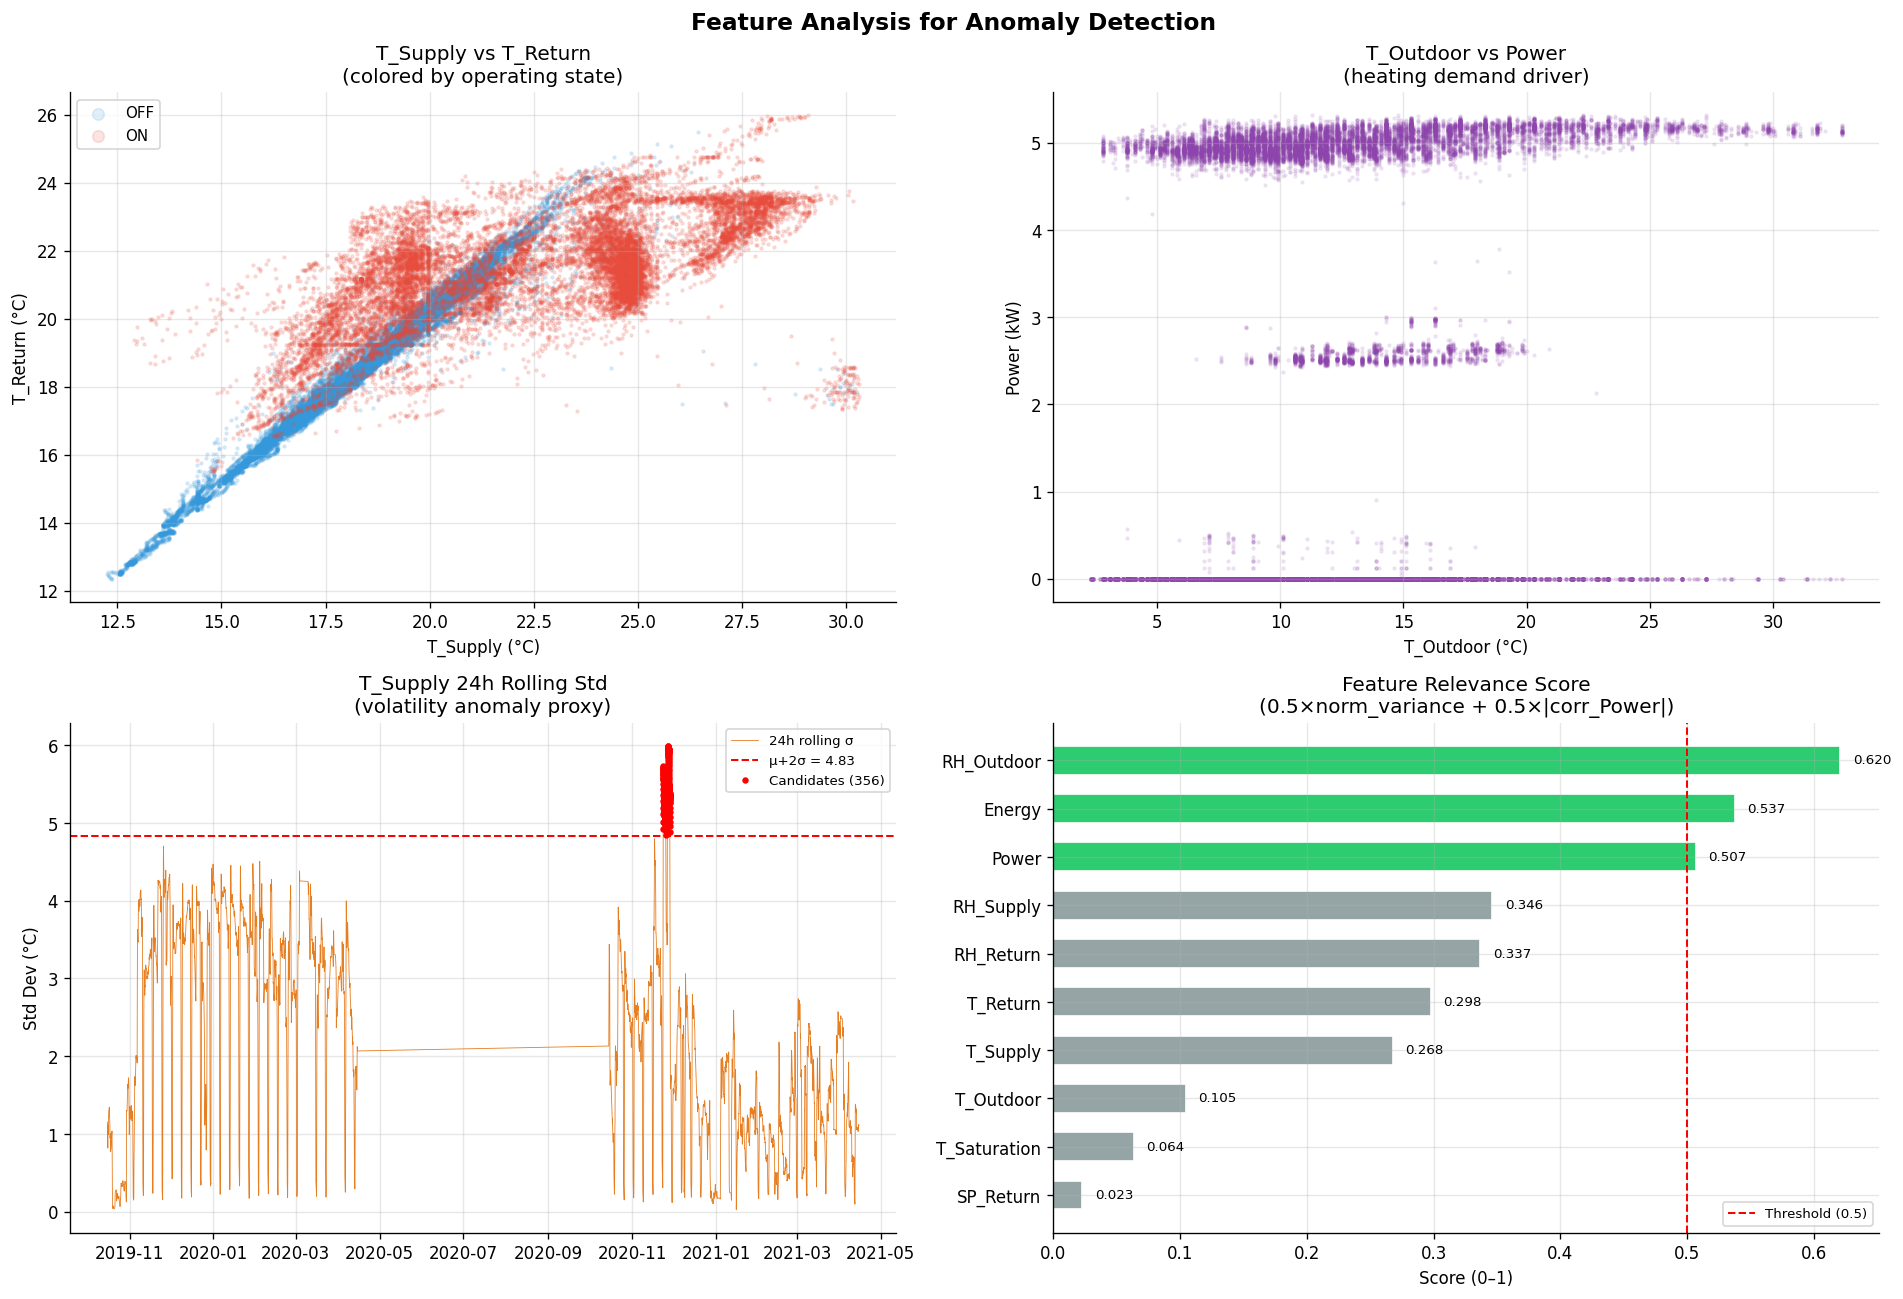

In [10]:
pal_op = {0: '#3498db', 1: '#e74c3c'}
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Feature Analysis for Anomaly Detection', fontsize=14, fontweight='bold')

# T_Supply vs T_Return by operating state
ax = axes[0, 0]
for state, grp in df.groupby('operating'):
    ax.scatter(grp['T_Supply'], grp['T_Return'], alpha=0.15, s=3,
               color=pal_op[state], label='OFF' if state == 0 else 'ON')
ax.set_xlabel('T_Supply (°C)'); ax.set_ylabel('T_Return (°C)')
ax.set_title('T_Supply vs T_Return\n(colored by operating state)')
ax.legend(markerscale=4, fontsize=9)

# T_Outdoor vs Power
ax = axes[0, 1]
ax.scatter(df['T_Outdoor'], df['Power'], alpha=0.1, s=3, c='#8e44ad')
ax.set_xlabel('T_Outdoor (°C)'); ax.set_ylabel('Power (kW)')
ax.set_title('T_Outdoor vs Power\n(heating demand driver)')

# Rolling std anomaly proxy
ax = axes[1, 0]
roll_std = df['T_Supply'].rolling(window=96).std()   # 96 × 15min = 24h
threshold = roll_std.mean() + 2 * roll_std.std()
ax.plot(df.index, roll_std, color='#e67e22', linewidth=0.5, label='24h rolling σ')
ax.axhline(threshold, color='red', linewidth=1.2, linestyle='--',
           label=f'μ+2σ = {threshold:.2f}')
spikes = roll_std[roll_std > threshold]
ax.scatter(spikes.index, spikes.values, color='red', s=8, zorder=5,
           label=f'Candidates ({len(spikes)})')
ax.set_title('T_Supply 24h Rolling Std\n(volatility anomaly proxy)')
ax.set_ylabel('Std Dev (°C)')
ax.legend(fontsize=8)
print(f"Anomaly candidates (rolling-std > μ+2σ): {len(spikes)} points "
      f"({len(spikes)/len(df)*100:.2f}%)")

# Feature relevance score
ax = axes[1, 1]
variances  = df[ALL_NUM].var()
corr_power = df[ALL_NUM].corrwith(df['Power']).abs()
score = ((variances / variances.max()) * 0.5
         + (corr_power / corr_power.max()) * 0.5).sort_values(ascending=True)
colors = ['#2ecc71' if s > 0.5 else '#95a5a6' for s in score]
ax.barh(score.index, score.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0.5, color='red', linewidth=1.2, linestyle='--', label='Threshold (0.5)')
ax.set_title('Feature Relevance Score\n(0.5×norm_variance + 0.5×|corr_Power|)')
ax.set_xlabel('Score (0–1)')
ax.legend(fontsize=8)
for i, (v, name) in enumerate(zip(score.values, score.index)):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('05_feature_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Final Feature Selection
Based on:
1. **Correlation with Power** (operating proxy)
2. **Variance** (signal richness)
3. **Domain knowledge** (temperature delta is a known HVAC health indicator)

In [11]:
SELECTED_FEATURES = ['T_Supply', 'T_Return', 'T_Outdoor', 'Power']

# Engineer T_delta
df['T_delta'] = df['T_Supply'] - df['T_Return']
SELECTED_FEATURES += ['T_delta']

DROPPED_FEATURES = [c for c in ALL_NUM if c not in SELECTED_FEATURES]

print("=" * 45)
print(f"✅ SELECTED ({len(SELECTED_FEATURES)}):", SELECTED_FEATURES)
print(f"❌ DROPPED  ({len(DROPPED_FEATURES)}):", DROPPED_FEATURES)
print("=" * 45)

df_selected = df[SELECTED_FEATURES].copy()
print(f"\nFinal dataframe shape : {df_selected.shape}")
print(f"Date range            : {df_selected.index.min()} → {df_selected.index.max()}")
df_selected.describe().T

✅ SELECTED (5): ['T_Supply', 'T_Return', 'T_Outdoor', 'Power', 'T_delta']
❌ DROPPED  (6): ['SP_Return', 'T_Saturation', 'RH_Supply', 'RH_Return', 'RH_Outdoor', 'Energy']

Final dataframe shape : (33888, 5)
Date range            : 2019-10-14 22:00:00+00:00 → 2021-04-14 21:45:00+00:00


,count,mean,std,min,25%,50%,75%,max
T_Supply,33888.0,20.436936,3.535683,12.264999,17.879999,19.785000,23.256249,30.295000
T_Return,33888.0,19.994425,2.357756,12.344999,18.389999,20.385000,21.699999,25.990000
T_Outdoor,33888.0,12.414164,4.925918,2.300000,8.900000,11.800000,15.300000,32.799999
Power,33888.0,2.308225,2.432835,0.000000,0.000000,0.000000,4.980000,5.316000
T_delta,33888.0,0.442512,2.073272,-6.805000,-0.415001,-0.140001,1.075000,12.840000


In [12]:
# Save cleaned dataset for Step 2 (Preprocessing)
df_selected.to_csv('hvac_eda_selected.csv')
print("💾 Saved → hvac_eda_selected.csv")

💾 Saved → hvac_eda_selected.csv


---
## ✅ EDA Complete

| Feature | Role |
|---|---|
| `T_Supply` | Primary temperature signal |
| `T_Return` | System return state |
| `T_Outdoor` | External demand driver |
| `Power` | Operating indicator / anomaly label proxy |
| `T_delta` | Engineered: Supply−Return difference (anomaly signal) |

**Next → Step 2: Preprocessing** (normalization, sliding window, train/test split)